# Week 11 수업 예제: Backpropagation 핵심

## 오늘의 주인공: 2-2-1 네트워크

- 입력 2개 → 은닉 2개 (sigmoid) → 출력 1개 (활성화 없음)
- 파라미터 9개 → 편미분 9개
- 손실: MSE `L = 1/2 (y - a²)²`

## 준비: 같은 폴더에 `mlp_scratch.py`가 있어야 합니다.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mlp_scratch import MLP, sigmoid, gradient_check



---
## 예제 1: Forward Pass 숫자 검증

**수업 슬라이드 7-8과 대응**

슬라이드에서 손으로 계산한 값들과 코드 출력을 대조합니다.

In [2]:
# 슬라이드와 동일한 설정
mlp = MLP(n_input=2, n_hidden=2, n_output=1)
mlp.W1 = np.array([[0.1, 0.2], [0.3, 0.4]])
mlp.b1 = np.array([0.0, 0.0])
mlp.W2 = np.array([[0.5, 0.6]])
mlp.b2 = np.array([0.0])

x = np.array([1.0, 1.0])
y = np.array([0.0])

# Forward pass
cache = mlp.forward_with_cache(x)

print("Forward pass 결과:")
print(f"  z⁽¹⁾ = {cache['z1']}")
print(f"  a⁽¹⁾ = {cache['a1']}")
print(f"  z⁽²⁾ = {cache['z2']}")
print(f"  a⁽²⁾ = {cache['a2']}")

L = 0.5 * (y - cache['a2'])**2
print(f"\nLoss L = {L[0]:.4f}")
print("\n슬라이드 5의 기대값과 일치해야 합니다:")
print("  a⁽¹⁾₀ ≈ 0.5744, a⁽¹⁾₁ ≈ 0.6682")
print("  a⁽²⁾ ≈ 0.6881, L ≈ 0.2368")

Forward pass 결과:
  z⁽¹⁾ = [0.3 0.7]
  a⁽¹⁾ = [0.57444252 0.66818777]
  z⁽²⁾ = [0.68813392]
  a⁽²⁾ = [0.68813392]

Loss L = 0.2368

슬라이드 5의 기대값과 일치해야 합니다:
  a⁽¹⁾₀ ≈ 0.5744, a⁽¹⁾₁ ≈ 0.6682
  a⁽²⁾ ≈ 0.6881, L ≈ 0.2368


---
## 예제 2: 출력층 편미분 (3개) 단계별 검증

**수업 슬라이드 6-9과 대응**

손으로 유도한 공식 `∂L/∂W⁽²⁾ᵢ = (a⁽²⁾ - y) · a⁽¹⁾ᵢ` 을 코드로 확인합니다.

In [3]:
# Step 1: ∂L/∂a⁽²⁾ (출발점)
dL_da2 = cache['a2'] - y
print(f"∂L/∂a⁽²⁾ = a⁽²⁾ - y = {dL_da2[0]:.4f}")
print(f"  (슬라이드 예상: 0.6881)")

# Step 2: 출력층 3개 편미분
print("\n출력층 편미분:")
a1 = cache['a1']
dW2 = np.outer(dL_da2, a1)  # (1, 2) = (오차) × (은닉 활성화)
db2 = dL_da2                 # (1,)

print(f"  ∂L/∂W⁽²⁾₀ = (a⁽²⁾-y) · a⁽¹⁾₀ = {dW2[0, 0]:.4f}  (예상 ≈ 0.3953)")
print(f"  ∂L/∂W⁽²⁾₁ = (a⁽²⁾-y) · a⁽¹⁾₁ = {dW2[0, 1]:.4f}  (예상 ≈ 0.4598)")
print(f"  ∂L/∂b⁽²⁾   = (a⁽²⁾-y)        = {db2[0]:.4f}       (예상 ≈ 0.6881)")

∂L/∂a⁽²⁾ = a⁽²⁾ - y = 0.6881
  (슬라이드 예상: 0.6881)

출력층 편미분:
  ∂L/∂W⁽²⁾₀ = (a⁽²⁾-y) · a⁽¹⁾₀ = 0.3953  (예상 ≈ 0.3953)
  ∂L/∂W⁽²⁾₁ = (a⁽²⁾-y) · a⁽¹⁾₁ = 0.4598  (예상 ≈ 0.4598)
  ∂L/∂b⁽²⁾   = (a⁽²⁾-y)        = 0.6881       (예상 ≈ 0.6881)


모든 값이 슬라이드의 손계산과 일치하나요? 만약 일치한다면, 출력층 backward를 완벽히 이해한 것입니다.

---
## 예제 3: 은닉층 편미분 (6개) — chain rule 5단계

**수업 슬라이드 10-15와 대응**

5단계 chain rule을 하나씩 코드로 풀어봅시다.

In [4]:
# Step 3: 에러를 은닉층으로 역전파
# ∂L/∂a⁽¹⁾ = W⁽²⁾ᵀ · ∂L/∂a⁽²⁾
dL_da1 = mlp.W2.T @ dL_da2
print(f"∂L/∂a⁽¹⁾ = W⁽²⁾ᵀ · (a⁽²⁾ - y)")
print(f"  = [{mlp.W2[0, 0]}, {mlp.W2[0, 1]}] × {dL_da2[0]:.4f}")
print(f"  = {dL_da1}")

# Step 4: sigmoid 미분 통과해서 δ⁽¹⁾ 얻기
# δ⁽¹⁾ᵢ = ∂L/∂a⁽¹⁾ᵢ · σ'(z⁽¹⁾ᵢ) = ∂L/∂a⁽¹⁾ᵢ · a⁽¹⁾ᵢ · (1 - a⁽¹⁾ᵢ)
delta1 = dL_da1 * a1 * (1.0 - a1)
print(f"\nδ⁽¹⁾ (에러 신호):")
print(f"  δ⁽¹⁾₀ = {delta1[0]:.4f}  (예상 ≈ 0.0841)")
print(f"  δ⁽¹⁾₁ = {delta1[1]:.4f}  (예상 ≈ 0.0915)")

# Step 5: 은닉층 가중치와 바이어스 편미분
# ∂L/∂W⁽¹⁾ᵢⱼ = δ⁽¹⁾ᵢ · xⱼ
dW1 = np.outer(delta1, x)
db1 = delta1

print(f"\n은닉층 편미분:")
print(f"  ∂L/∂W⁽¹⁾₀₀ = δ⁽¹⁾₀·x₀ = {dW1[0, 0]:.4f}  (예상 ≈ 0.0841)")
print(f"  ∂L/∂W⁽¹⁾₀₁ = δ⁽¹⁾₀·x₁ = {dW1[0, 1]:.4f}  (예상 ≈ 0.0841)")
print(f"  ∂L/∂W⁽¹⁾₁₀ = δ⁽¹⁾₁·x₀ = {dW1[1, 0]:.4f}  (예상 ≈ 0.0915)")
print(f"  ∂L/∂W⁽¹⁾₁₁ = δ⁽¹⁾₁·x₁ = {dW1[1, 1]:.4f}  (예상 ≈ 0.0915)")
print(f"  ∂L/∂b⁽¹⁾₀  = δ⁽¹⁾₀    = {db1[0]:.4f}")
print(f"  ∂L/∂b⁽¹⁾₁  = δ⁽¹⁾₁    = {db1[1]:.4f}")

∂L/∂a⁽¹⁾ = W⁽²⁾ᵀ · (a⁽²⁾ - y)
  = [0.5, 0.6] × 0.6881
  = [0.34406696 0.41288035]

δ⁽¹⁾ (에러 신호):
  δ⁽¹⁾₀ = 0.0841  (예상 ≈ 0.0841)
  δ⁽¹⁾₁ = 0.0915  (예상 ≈ 0.0915)

은닉층 편미분:
  ∂L/∂W⁽¹⁾₀₀ = δ⁽¹⁾₀·x₀ = 0.0841  (예상 ≈ 0.0841)
  ∂L/∂W⁽¹⁾₀₁ = δ⁽¹⁾₀·x₁ = 0.0841  (예상 ≈ 0.0841)
  ∂L/∂W⁽¹⁾₁₀ = δ⁽¹⁾₁·x₀ = 0.0915  (예상 ≈ 0.0915)
  ∂L/∂W⁽¹⁾₁₁ = δ⁽¹⁾₁·x₁ = 0.0915  (예상 ≈ 0.0915)
  ∂L/∂b⁽¹⁾₀  = δ⁽¹⁾₀    = 0.0841
  ∂L/∂b⁽¹⁾₁  = δ⁽¹⁾₁    = 0.0915


---
## 예제 4: MLP.backward()로 한 번에 계산

**수업 슬라이드 26과 대응**

위에서 단계별로 한 것을 `backward()` 메서드로 한 번에 실행합니다.

In [5]:
grads = mlp.backward(cache, y)

print("mlp.backward() 한 번 호출로 9개 편미분 모두 계산:")
print(f"\n출력층:")
print(f"  dW2 = {grads['dW2']}")
print(f"  db2 = {grads['db2']}")
print(f"\n은닉층:")
print(f"  dW1 = \n{grads['dW1']}")
print(f"  db1 = {grads['db1']}")

# 위에서 단계별로 계산한 것과 일치 확인
assert np.allclose(grads['dW2'], dW2), "dW2 불일치"
assert np.allclose(grads['dW1'], dW1), "dW1 불일치"
print("\n✓ 단계별 계산과 backward() 결과가 완벽 일치")

mlp.backward() 한 번 호출로 9개 편미분 모두 계산:

출력층:
  dW2 = [[0.39529338 0.45980267]]
  db2 = [0.68813392]

은닉층:
  dW1 = 
[[0.08411003 0.08411003]
 [0.09154089 0.09154089]]
  db1 = [0.08411003 0.09154089]

✓ 단계별 계산과 backward() 결과가 완벽 일치


---
## 예제 5: Gradient Check — 수치 미분 vs 분석 미분

**수업 슬라이드 29-31과 대응**

우리의 backward 구현이 정말 맞는지 **수치 미분**으로 검증합니다.

In [6]:
# gradient_check는 각 파라미터마다:
#   1. 분석 미분 (backward로 계산)
#   2. 수치 미분 ((L(W+ε) - L(W-ε)) / 2ε)
# 를 비교해서 최대 상대 오차를 반환

max_rel_err = gradient_check(mlp, x, y)

print(f"최대 상대 오차: {max_rel_err:.2e}")
print()
if max_rel_err < 1e-7:
    print("✓ 완벽! backward 구현이 정확합니다.")
elif max_rel_err < 1e-5:
    print("△ 작은 오차. 대체로 맞음 (수치 오차 범위).")
else:
    print("✗ 구현에 오류가 있습니다!")

최대 상대 오차: 7.02e-12

✓ 완벽! backward 구현이 정확합니다.


---
## 예제 6: 수치 미분 상세 비교 (표로)

각 파라미터의 분석 미분과 수치 미분을 병렬로 출력합니다.

In [7]:
def numerical_partial(mlp, param_name, index, x, y, eps=1e-5):
    """주어진 파라미터의 (index)번째 원소에 대해 수치 미분 계산."""
    param = getattr(mlp, param_name)
    original = param[index].copy() if hasattr(param[index], 'copy') else param[index]
    
    # L(W + ε)
    param[index] = original + eps
    cache_plus = mlp.forward_with_cache(x)
    L_plus = 0.5 * float((y - cache_plus['a2'])**2)
    
    # L(W - ε)
    param[index] = original - eps
    cache_minus = mlp.forward_with_cache(x)
    L_minus = 0.5 * float((y - cache_minus['a2'])**2)
    
    # 복원
    param[index] = original
    
    return (L_plus - L_minus) / (2 * eps)

# 분석 미분
grads = mlp.backward(cache, y)

print("파라미터       | 분석 미분      | 수치 미분      | 차이")
print("-" * 65)

# W1의 4개 원소
for i in range(2):
    for j in range(2):
        ana = grads['dW1'][i, j]
        num = numerical_partial(mlp, 'W1', (i, j), x, y)
        print(f"W⁽¹⁾_{i}{j}        | {ana:+.8f}  | {num:+.8f}  | {abs(ana-num):.2e}")

# b1의 2개
for i in range(2):
    ana = grads['db1'][i]
    num = numerical_partial(mlp, 'b1', i, x, y)
    print(f"b⁽¹⁾_{i}         | {ana:+.8f}  | {num:+.8f}  | {abs(ana-num):.2e}")

# W2의 2개
for j in range(2):
    ana = grads['dW2'][0, j]
    num = numerical_partial(mlp, 'W2', (0, j), x, y)
    print(f"W⁽²⁾_{j}         | {ana:+.8f}  | {num:+.8f}  | {abs(ana-num):.2e}")

# b2
ana = grads['db2'][0]
num = numerical_partial(mlp, 'b2', 0, x, y)
print(f"b⁽²⁾          | {ana:+.8f}  | {num:+.8f}  | {abs(ana-num):.2e}")

파라미터       | 분석 미분      | 수치 미분      | 차이
-----------------------------------------------------------------
W⁽¹⁾_00        | +0.08411003  | +0.08411003  | 6.20e-14
W⁽¹⁾_01        | +0.08411003  | +0.08411003  | 6.20e-14
W⁽¹⁾_10        | +0.09154089  | +0.09154089  | 1.74e-13
W⁽¹⁾_11        | +0.09154089  | +0.09154089  | 1.74e-13
b⁽¹⁾_0         | +0.08411003  | +0.08411003  | 6.20e-14
b⁽¹⁾_1         | +0.09154089  | +0.09154089  | 1.74e-13
W⁽²⁾_0         | +0.39529338  | +0.39529338  | 1.59e-12
W⁽²⁾_1         | +0.45980267  | +0.45980267  | 3.23e-12
b⁽²⁾          | +0.68813392  | +0.68813392  | 3.76e-12


C:\Users\yongo\AppData\Local\Temp\ipykernel_12056\1699651842.py:9: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  L_plus = 0.5 * float((y - cache_plus['a2'])**2)
C:\Users\yongo\AppData\Local\Temp\ipykernel_12056\1699651842.py:14: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  L_minus = 0.5 * float((y - cache_minus['a2'])**2)


모든 차이가 `1e-9` 이하여야 합니다. 이것이 여러분의 backward 구현이 **수식적으로 정확함**을 증명합니다.

---
## 예제 7: XOR 자동 학습!

**수업 슬라이드 32와 대응**

Week 9에서 손으로 설계한 XOR를 이제 **backprop으로 자동 학습**합니다.

In [8]:
# XOR 데이터 (0/1 버전)
X_xor = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
Y_xor = np.array([[0], [1], [1], [0]])

# 새 MLP 만들고 XOR 학습
np.random.seed(42)
mlp_xor = MLP(n_input=2, n_hidden=2, n_output=1)

history = mlp_xor.train(X_xor, Y_xor, epochs=10000, lr=0.5, verbose=True)

# 학습 후 예측
print("\n학습 후 예측:")
print("x₁ x₂  | 예측    | 정답")
print("-" * 30)
for x_test, y_true in zip(X_xor, Y_xor):
    cache = mlp_xor.forward_with_cache(x_test)
    pred = cache['a2'][0]
    print(f"{x_test[0]}  {x_test[1]}   | {pred:.4f}  | {y_true[0]}")

Epoch     0: loss = 0.326636
Epoch  1000: loss = 0.072744
Epoch  2000: loss = 0.000000
Epoch  3000: loss = 0.000000
Epoch  4000: loss = 0.000000
Epoch  5000: loss = 0.000000
Epoch  6000: loss = 0.000000
Epoch  7000: loss = 0.000000
Epoch  8000: loss = 0.000000
Epoch  9000: loss = 0.000000

학습 후 예측:
x₁ x₂  | 예측    | 정답
------------------------------
0  0   | 0.0000  | 0
0  1   | 1.0000  | 1
1  0   | 1.0000  | 1
1  1   | 0.0000  | 0


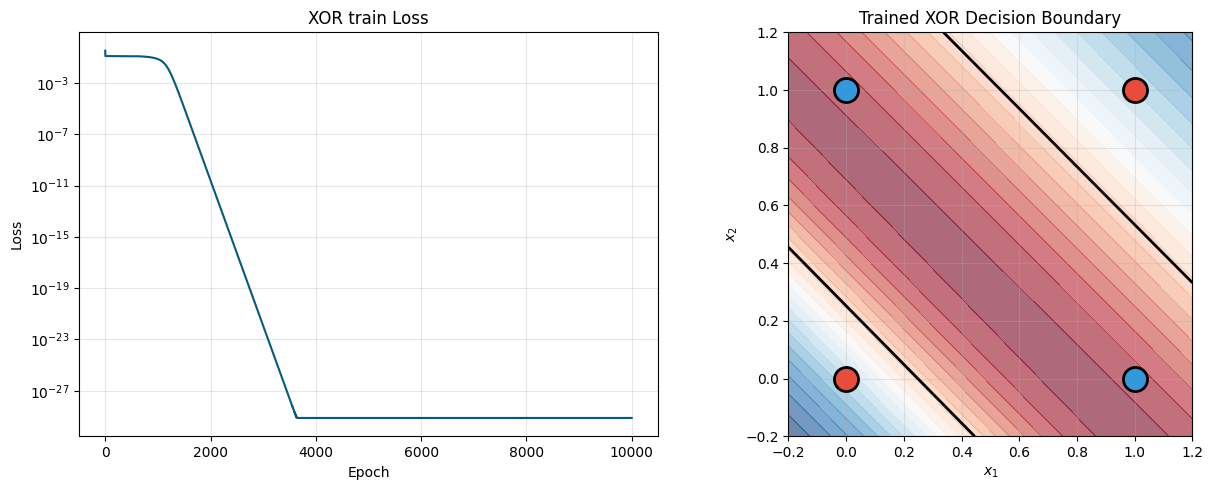


이것이 '학습'입니다 — backprop이 자동으로 올바른 가중치를 찾았습니다!


In [10]:
# Loss curve 시각화
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# 왼쪽: Loss curve
ax = axes[0]
ax.plot(history, color='#065A82', linewidth=1.5)
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("XOR train Loss")
ax.set_yscale('log')
ax.grid(alpha=0.3)

# 오른쪽: Decision boundary
ax = axes[1]
xs = np.linspace(-0.2, 1.2, 100)
ys = np.linspace(-0.2, 1.2, 100)
X_grid, Y_grid = np.meshgrid(xs, ys)
Z = np.zeros_like(X_grid)
for i in range(X_grid.shape[0]):
    for j in range(X_grid.shape[1]):
        pt = np.array([X_grid[i, j], Y_grid[i, j]])
        Z[i, j] = mlp_xor.forward_with_cache(pt)['a2'][0]

ax.contourf(X_grid, Y_grid, Z, levels=20, cmap='RdBu_r', alpha=0.6)
ax.contour(X_grid, Y_grid, Z, levels=[0.5], colors='black', linewidths=2)

for pt, label in zip(X_xor, Y_xor):
    color = '#3498DB' if label[0] == 1 else '#E74C3C'
    ax.scatter(pt[0], pt[1], c=color, s=300, edgecolor='black', linewidth=2, zorder=5)

ax.set_title("Trained XOR Decision Boundary")
ax.set_xlabel("$x_1$"); ax.set_ylabel("$x_2$")
ax.set_aspect('equal'); ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\n이것이 '학습'입니다 — backprop이 자동으로 올바른 가중치를 찾았습니다!")

---
## 오늘의 마무리

### 오늘 우리가 달성한 것

1. **Forward pass를 손으로 계산** → 코드 결과와 일치 (슬라이드 7-8)
2. **9개 편미분을 손으로 유도** → 모두 (δ × 입력) 패턴
3. **NumPy로 backward 구현** → 수식과 1:1 대응
4. **Gradient check로 검증** → 차이 < 10⁻⁷ (거의 완벽)
5. **XOR 자동 학습 성공** → Week 9의 하드코딩이 이제 자동화됨

### 이것이 backpropagation입니다.

오늘 2-2-1에서 한 것을 Week 12에서는 **임의 구조**로 확장합니다. 원리는 동일합니다.

## 다음

- `week11_exercises.ipynb` — 빈칸 채우기 연습
- `week11_homework.ipynb` — 과제